
Training BiRNN...
Epoch 5/20, Loss: 0.01099
Epoch 10/20, Loss: 0.00417
Epoch 15/20, Loss: 0.00350
Epoch 20/20, Loss: 0.00353

Training Feedforward NN...
Epoch 5/20, Loss: 0.00539
Epoch 10/20, Loss: 0.00380
Epoch 15/20, Loss: 0.00308
Epoch 20/20, Loss: 0.00246

----- Model Performance -----
BiRNN MSE: 2386.753
FFNN MSE: 1957.495


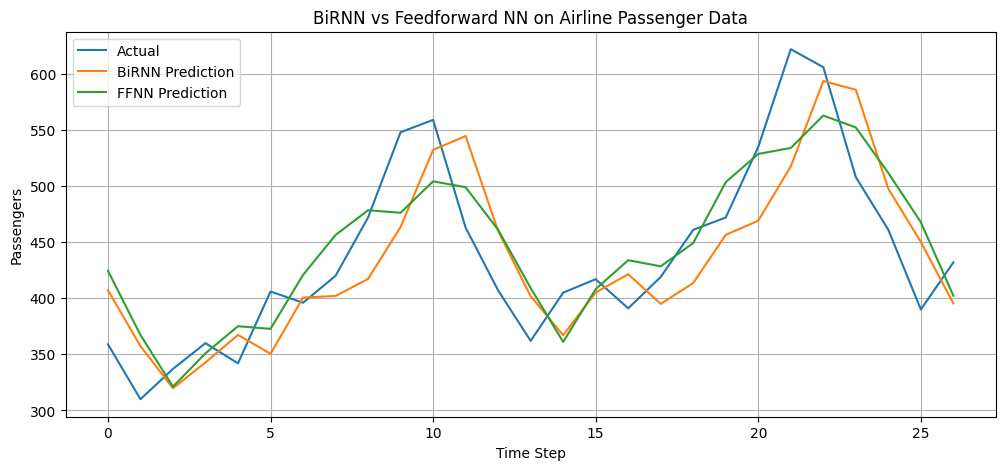

In [1]:
# EX 6: BiRNN VS FEEDFORWARD NN FOR TIME-SERIES PREDICTION

# Step 1: Import Libraries

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader


# Step 2: Load Airline Passenger Dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv"

df = pd.read_csv(url, usecols=[1])

data = df.values.astype("float32")

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)


# Step 3: Create Sequences

SEQ_LENGTH = 10

X = []
y = []

for i in range(len(data_scaled) - SEQ_LENGTH):
    X.append(data_scaled[i:i + SEQ_LENGTH])
    y.append(data_scaled[i + SEQ_LENGTH])

X = np.array(X)
y = np.array(y)

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


# Step 4: Convert to PyTorch Tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=16,
    shuffle=True
)


# Step 5: Define Small BiRNN

class BiRNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=16,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        out, _ = self.rnn(x)

        return self.fc(out[:, -1, :])


# Step 6: Define Feedforward NN

class FeedforwardNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(10, 16)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        return self.fc2(x)


# Step 7: Training Function

def train_model(model, loader, epochs=20):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for seqs, targets in loader:

            optimizer.zero_grad()

            outputs = model(seqs)

            loss = criterion(outputs, targets)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:

            print(
                f"Epoch {epoch + 1}/{epochs}, "
                f"Loss: {total_loss / len(loader):.5f}"
            )


# Step 8: Train BiRNN

print("\nTraining BiRNN...")

birnn = BiRNN()

train_model(birnn, train_loader)


# Step 9: Train Feedforward NN

print("\nTraining Feedforward NN...")

ffnn = FeedforwardNN()

train_model(ffnn, train_loader)


# Step 10: Make Predictions

birnn.eval()
ffnn.eval()

with torch.no_grad():

    pred_birnn = birnn(X_test).numpy()

    pred_ffnn = ffnn(X_test).numpy()


# Step 11: Convert Back to Original Scale

pred_birnn_inv = scaler.inverse_transform(
    pred_birnn
)

pred_ffnn_inv = scaler.inverse_transform(
    pred_ffnn
)

y_test_inv = scaler.inverse_transform(
    y_test.numpy()
)


# Step 12: Calculate MSE

mse_birnn = mean_squared_error(
    y_test_inv,
    pred_birnn_inv
)

mse_ffnn = mean_squared_error(
    y_test_inv,
    pred_ffnn_inv
)


# Step 13: Display MSE

print("\n----- Model Performance -----")

print(
    f"BiRNN MSE: {mse_birnn:.3f}"
)

print(
    f"FFNN MSE: {mse_ffnn:.3f}"
)


# Step 14: Plot Predictions

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_inv,
    label="Actual"
)

plt.plot(
    pred_birnn_inv,
    label="BiRNN Prediction"
)

plt.plot(
    pred_ffnn_inv,
    label="FFNN Prediction"
)

plt.title(
    "BiRNN vs Feedforward NN on Airline Passenger Data"
)

plt.xlabel("Time Step")

plt.ylabel("Passengers")

plt.legend()

plt.grid(True)

plt.show()